In [2]:
# importing libraries
import pandas as pd
import matplotlib.pyplot
import seaborn as sns
import numpy as np

In [3]:

import matplotlib.pyplot as plt

In [4]:
# setting color pallete
sns.set_palette('Greys_d')

In [5]:
# Reading dataset
df = pd.read_csv('/workspaces/Python-Project/Data/california_housing_prices.csv')

In [6]:
# inspecting first few rows
df.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41,880,129.0,322,126,8.3252,452600,NEAR BAY
1,-122.22,37.86,21,7099,1106.0,2401,1138,8.3014,358500,NEAR BAY
2,-122.24,37.85,52,1467,190.0,496,177,7.2574,352100,NEAR BAY
3,-122.25,37.85,52,1274,235.0,558,219,5.6431,341300,NEAR BAY
4,-122.25,37.85,52,1627,280.0,565,259,3.8462,342200,NEAR BAY


In [7]:
# Inspecting shape
print(f'California Housing Dataset {df.shape[0]} rows and {df.shape[1]} columns')

California Housing Dataset 20640 rows and 10 columns


In [8]:
# inspecting duplicate records
print(f'California Housing Dataset {sum(df.duplicated())} duplicated record(s)')

California Housing Dataset 0 duplicated record(s)


In [9]:
# Data info
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  int64  
 3   total_rooms         20640 non-null  int64  
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  int64  
 6   households          20640 non-null  int64  
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  int64  
 9   ocean_proximity     20640 non-null  str    
dtypes: float64(4), int64(5), str(1)
memory usage: 1.6 MB


In [10]:
# Missing values
round(df.isnull().sum() * 100 / df.shape[0],2)

longitude             0.0
latitude              0.0
housing_median_age    0.0
total_rooms           0.0
total_bedrooms        1.0
population            0.0
households            0.0
median_income         0.0
median_house_value    0.0
ocean_proximity       0.0
dtype: float64

In [11]:
# statistical description
df[['housing_median_age', 'total_rooms', 'total_bedrooms', 'population', 'households', 'median_income', 'median_house_value']].describe()

,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,20640.000000,20640.000000,20433.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,28.639486,2635.763081,537.870553,1425.476744,499.539680,3.870671,206855.816909
std,12.585558,2181.615252,421.385070,1132.462122,382.329753,1.899822,115395.615874
min,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000
25%,18.000000,1447.750000,296.000000,787.000000,280.000000,2.563400,119600.000000
50%,29.000000,2127.000000,435.000000,1166.000000,409.000000,3.534800,179700.000000
75%,37.000000,3148.000000,647.000000,1725.000000,605.000000,4.743250,264725.000000
max,52.000000,39320.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000


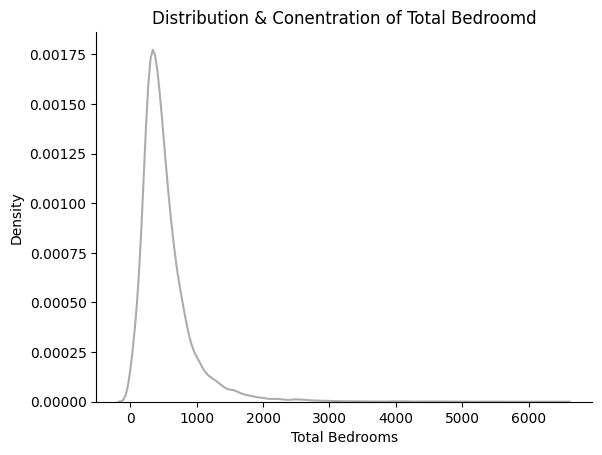

In [12]:
# distribution and concentration of total bedrooms
sns.kdeplot(data = df, x = 'total_bedrooms')
plt.title('Distribution & Conentration of Total Bedroomd')
plt.xlabel('Total Bedrooms')
plt.gca().spines[['top', 'right']].set_visible(False)
plt.show()

The visualization indicates a right-skewed distribution where most properties have a moderate number of bedrooms, with the highest concentration in the lower range. As bedroom count increases, the frequency decreases sharply, forming a long tail up to very high values (6000+), which suggests the presence of rare extreme cases or possible data errors. Overall, typical properties have moderate bedroom counts, while unusually large values are infrequent and may require further investigation or data cleaning.

In [13]:
# importing missing values in total bedrooms with median
df['total_bedrooms'] = df['total_bedrooms'].fillna(df['total_bedrooms'].median())

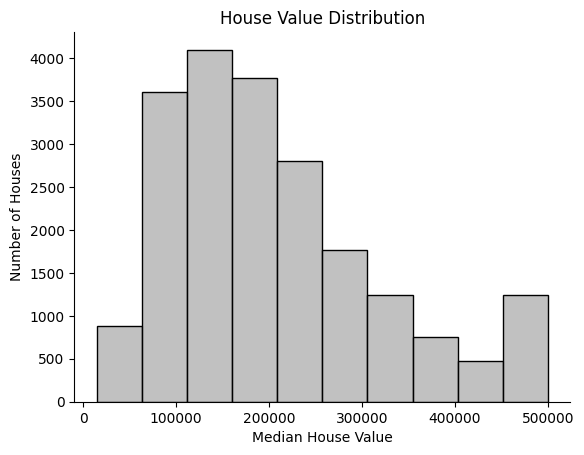

In [14]:
# how house values distributed

sns.histplot(data = df, x = 'median_house_value', binwidth = 50000)
plt.title('House Value Distribution')
plt.xlabel('Median House Value')
plt.ylabel('Number of Houses')
plt.gca().spines[['top', 'right']].set_visible(False)
plt.show()

This histogram shows that most houses fall in the 100,000–250,000 range, making it the most common segment. The distribution is right-skewed, with fewer high-priced homes extending up to 500,000. Very low-priced houses (below 100,000) are limited, and the number of houses decreases steadily beyond 300,000, showing that high-end properties are less common.


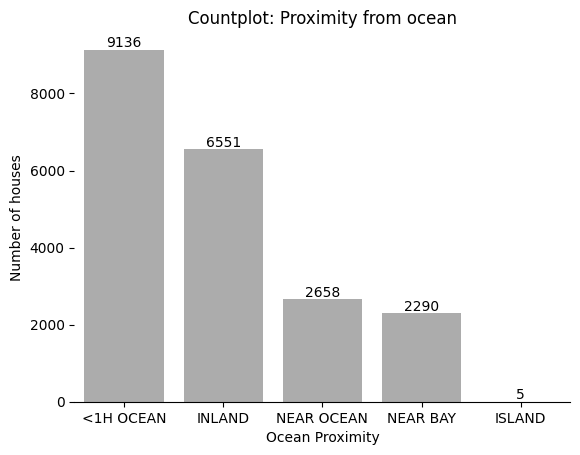

In [15]:
#how many housing blocks fall  into each ocean_proximity category?
fig = sns.countplot(data = df, x ='ocean_proximity', order = df['ocean_proximity'].value_counts().index)

for p in fig.patches:
    plt.text(p.get_x() + p.get_width() / 2, p.get_height(), f'{int(p.get_height())}', ha = 'center', va = 'bottom')

plt.title('Countplot: Proximity from ocean')
plt.xlabel('Ocean Proximity')
plt.ylabel('Number of houses')
plt.gca().spines[['top','left','right']].set_visible(False)
plt.show()

The visualization shows that most houses are located within one hour of the ocean, followed by a large number of inland properties. In comparison, fewer houses are situated near the ocean or near the bay, indicating these locations are less common and possibly more exclusive. The island category has a negligible count. Overall, the chart highlights that while many homes are relatively close to the coast, only a smaller share are in prime waterfront areas.

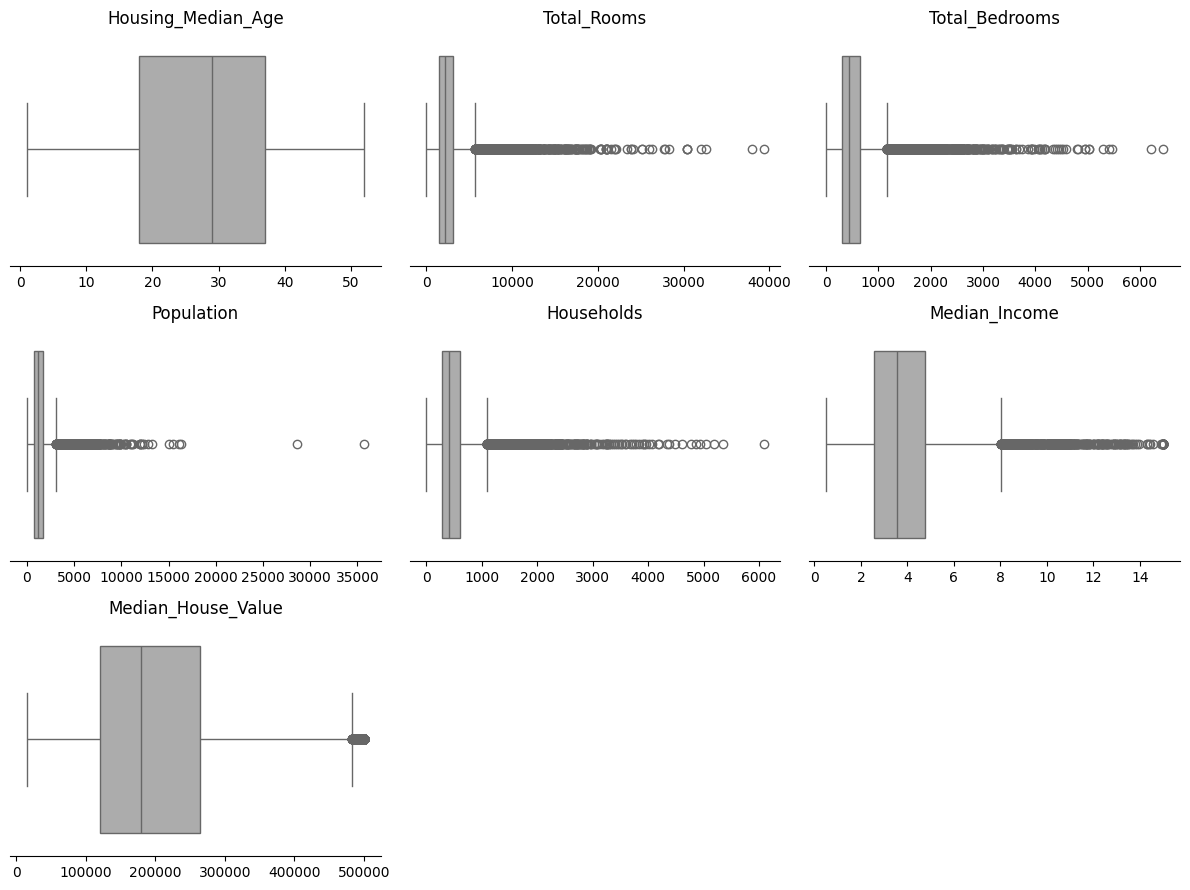

In [16]:
# outlier detection using boxplot 
# columns  to plot
cols = ['housing_median_age','total_rooms', 'total_bedrooms', 'population', 'households', 'median_income', 'median_house_value']

# subplot
fig, axs = plt.subplots(nrows = 3, ncols = 3, figsize = (12, 9))
axs = axs.flatten()

# iterate through columns and axes
for i, col in enumerate(cols):
    sns.boxplot(data= df, x = col, ax = axs[i])
    axs[i].set_title(col.replace(' ',' ').title())
    axs[i].set_xlabel('')
    axs[i].set_ylabel('')
    axs[i].set_yticks([])
    axs[i].spines[['top', 'left', 'right']].set_visible(False)

# hiding through columns axes
for j in range(len(cols), len(axs)):
   axs[j].set_visible(False)    

plt.tight_layout()
plt.show()   

The box plots show that most housing variables are right-skewed with many outliers, meaning a few areas have extremely high values compared to the majority. Housing age is more evenly distributed, while median income and house value are slightly skewed, with house prices showing a clear upper limit.

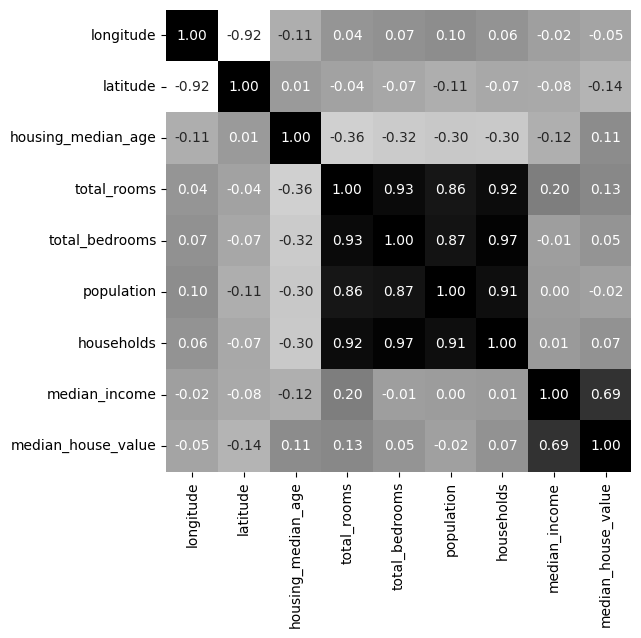

In [17]:
# correlation
plt.figure(figsize = (6, 6))
sns.heatmap(df.drop('ocean_proximity', axis = 1).corr(), annot = True, fmt = '.2f', cmap = 'Greys', cbar = False)
plt.show()

The heatmap shows that size-related features such as total rooms, total bedrooms, population, and households are strongly correlated with each other, indicating multicollinearity. Among all variables, median income has the strongest positive relationship with house prices, making it the most influential factor. In contrast, most other features have weak correlations with median house value, suggesting limited direct impact.
Additionally, location factors like latitude show a slight negative relationship with house prices, while housing median age has only a weak overall influence.

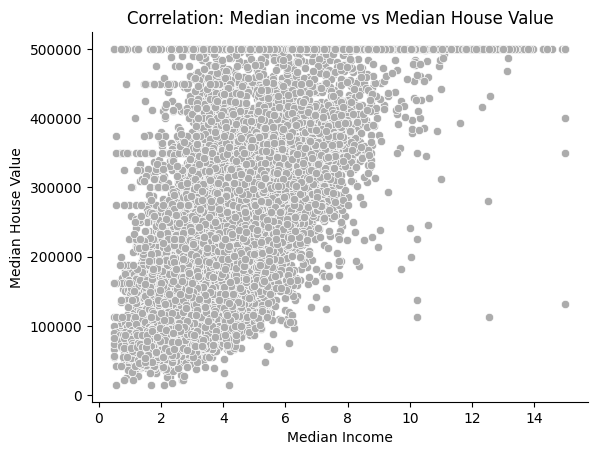

In [18]:
# correlation between median income and median_house_vaslue using scatterplot
sns.scatterplot(data = df, x = 'median_income', y ='median_house_value')
plt.title('Correlation: Median income vs Median House Value')
plt.xlabel('Median Income')
plt.ylabel('Median House Value')
plt.gca().spines[['top','right']].set_visible(False)
plt.show()

The scatter plot shows a clear positive relationship between median income and median house value, indicating that as income increases, house prices generally rise. However, the data points are widely spread, suggesting variability and that income alone does not fully determine house prices. There is also a noticeable price ceiling around 500,000, where many values are capped, which may indicate a limitation in the dataset.
Additionally, most data points are concentrated in the mid-income range, showing that the majority of observations fall within moderate income levels, with fewer high-income outliers.

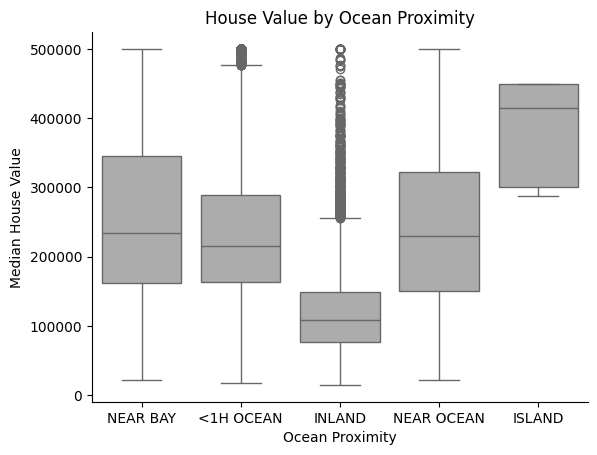

In [19]:
# how doees proximity to the ocean influences house price
sns.boxplot(data = df, x = 'ocean_proximity', y = 'median_house_value')
plt.title('House Value by Ocean Proximity')
plt.xlabel('Ocean Proximity')
plt.ylabel('Median House Value')
plt.gca().spines[['top','right']].set_visible(False)
plt.show()

The visualization shows that house prices rise as proximity to the ocean increases, with island and near-ocean properties being the most expensive, while inland homes are the least costly and show more price variation.

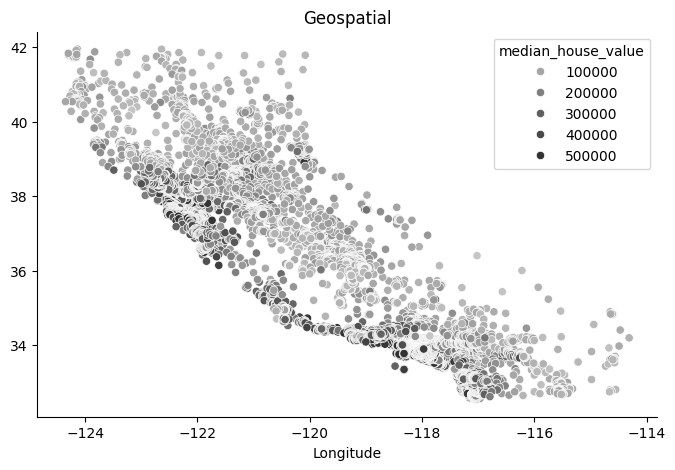

In [20]:
# geospatial distribution - how are house prices distributed geograohically
plt.figure(figsize = (8, 5))
sns.scatterplot(data = df, x = 'longitude', y = 'latitude', hue = 'median_house_value', palette = 'Greys_d')
plt.title('Geospatial')
plt.xlabel('Longitude')
plt.ylabel('')
plt.gca().spines[['top', 'right']].set_visible(False)
plt.show()

The visualization highlights a strong relationship between location and housing prices, where coastal and urban areas have higher property values, while inland regions tend to be more affordable.

In [21]:
# feature engineering
df['rooms_per_household'] = df['total_rooms'] / df['households']
df['bedrooms_per_room'] = df['total_bedrooms'] / df['total_rooms']
df['population_per_household'] = df['population'] / df['households']
df['income_per_household'] = df['median_income'] / df['households']
df['bedrooms_per_person'] = df['total_bedrooms'] / df['population']
df['rooms_per_person'] = df['total_rooms'] / df['population']
df['region'] = pd.cut(df['latitude'], bins = [32, 34, 36, 38, 40, 42], labels = ['South', 'Lower central', 'Central', 'North central', 'North' ])
df.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity,rooms_per_household,bedrooms_per_room,population_per_household,income_per_household,bedrooms_per_person,rooms_per_person,region
0,-122.23,37.88,41,880,129.0,322,126,8.3252,452600,NEAR BAY,6.984127,0.146591,2.555556,0.066073,0.400621,2.732919,Central
1,-122.22,37.86,21,7099,1106.0,2401,1138,8.3014,358500,NEAR BAY,6.238137,0.155797,2.109842,0.007295,0.460641,2.956685,Central
2,-122.24,37.85,52,1467,190.0,496,177,7.2574,352100,NEAR BAY,8.288136,0.129516,2.802260,0.041002,0.383065,2.957661,Central
3,-122.25,37.85,52,1274,235.0,558,219,5.6431,341300,NEAR BAY,5.817352,0.184458,2.547945,0.025768,0.421147,2.283154,Central
4,-122.25,37.85,52,1627,280.0,565,259,3.8462,342200,NEAR BAY,6.281853,0.172096,2.181467,0.014850,0.495575,2.879646,Central


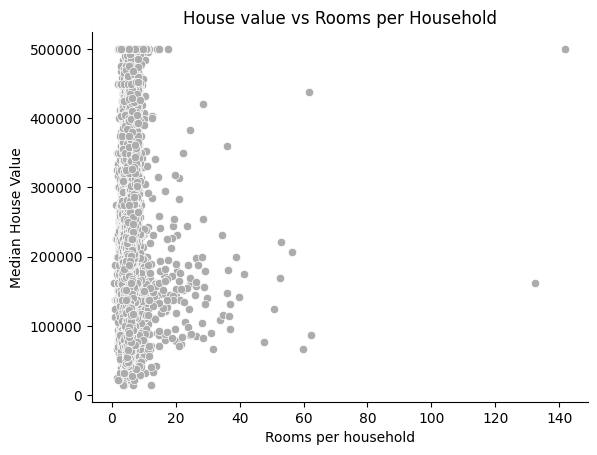

In [22]:
#relation between
sns.scatterplot(data = df, x = 'rooms_per_household', y = 'median_house_value')
plt.title('House value vs Rooms per Household')
plt.xlabel('Rooms per household')
plt.ylabel('Median House Value')
plt.gca().spines[['top', 'right']].set_visible(False)
plt.show()

The visualization shows a weak relationship between rooms per household and median house value, indicating that having more rooms does not strongly increase house prices. Most data points are concentrated in lower room ranges (around 0-10), with a wide variation in prices, suggesting other factors significantly influence house value. The presence of a price cap near 500,000 and a few extreme outliers further highlights limitations in the data. Overall, rooms per household alone is not a reliable predictor of housing prices.

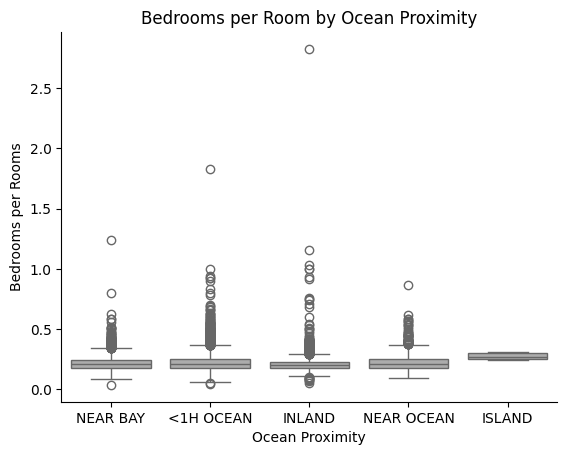

In [23]:
# proportion of bedrooms to total rooms by ocean proximity
sns.boxplot(data = df, x = 'ocean_proximity', y = 'bedrooms_per_room')
plt.title('Bedrooms per Room by Ocean Proximity')
plt.xlabel('Ocean Proximity')
plt.ylabel('Bedrooms per Rooms')
plt.gca().spines[['top', 'right']].set_visible(False)
plt.show()

The plot shows that bedrooms-per-room ratios are similar across all ocean proximity categories, mostly ranging between 0.1 and 0.3. There is little variation by location, though a few outliers exist, especially inland and near the ocean. Overall, ocean proximity has minimal impact on bedroom density.

In [24]:
# population per household bins
df['population_per_household_bins'] = pd.cut(df['population_per_household'], bins = [0, 2, 4, 6, np.inf], labels = ['<2', '2-4', '4-6', '6+'])
df.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity,rooms_per_household,bedrooms_per_room,population_per_household,income_per_household,bedrooms_per_person,rooms_per_person,region,population_per_household_bins
0,-122.23,37.88,41,880,129.0,322,126,8.3252,452600,NEAR BAY,6.984127,0.146591,2.555556,0.066073,0.400621,2.732919,Central,2-4
1,-122.22,37.86,21,7099,1106.0,2401,1138,8.3014,358500,NEAR BAY,6.238137,0.155797,2.109842,0.007295,0.460641,2.956685,Central,2-4
2,-122.24,37.85,52,1467,190.0,496,177,7.2574,352100,NEAR BAY,8.288136,0.129516,2.802260,0.041002,0.383065,2.957661,Central,2-4
3,-122.25,37.85,52,1274,235.0,558,219,5.6431,341300,NEAR BAY,5.817352,0.184458,2.547945,0.025768,0.421147,2.283154,Central,2-4
4,-122.25,37.85,52,1627,280.0,565,259,3.8462,342200,NEAR BAY,6.281853,0.172096,2.181467,0.014850,0.495575,2.879646,Central,2-4


In [25]:
# median house value vs population per household
df.groupby('population_per_household_bins', observed = True)['median_house_value'].median()

population_per_household_bins
<2     248100.0
2-4    184000.0
4-6    141500.0
6+     158700.0
Name: median_house_value, dtype: float64

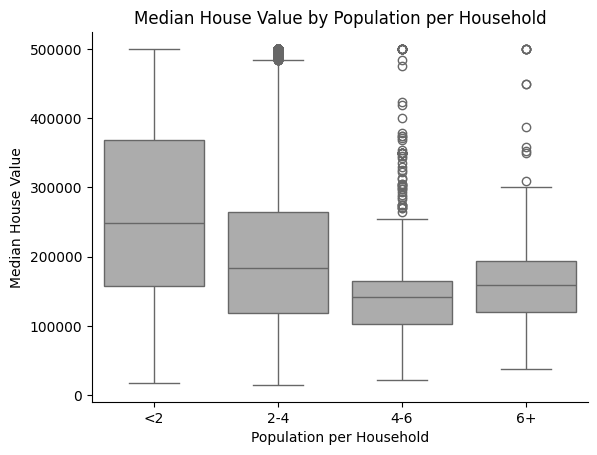

In [26]:
# average number of people per household vs median house price
sns.boxplot(data = df, x = 'population_per_household_bins', y = 'median_house_value')
plt.title('Median House Value by Population per Household')
plt.xlabel('Population per Household')
plt.ylabel('Median House Value')
plt.gca().spines[['top', 'right']].set_visible(False)
plt.show()

The chart shows that median house values generally decrease as population per household increases. Smaller households tend to have higher and more varied house prices, while larger households are associated with lower-priced homes, with a few high-value outliers present in all groups.

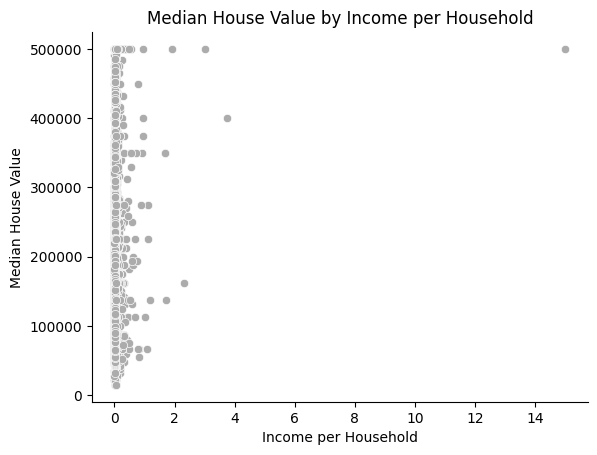

In [27]:
# income per household vs median house value
sns.scatterplot(data = df, x = 'income_per_household', y = 'median_house_value')
plt.title('Median House Value by Income per Household')
plt.xlabel('Income per Household')
plt.ylabel('Median House Value')
plt.gca().spines[['top', 'right']].set_visible(False)
plt.show()
plt.show()

The plot shows that higher household income is generally associated with higher house values. Most data is concentrated at lower income levels, with a price cap around 500,000 and a few extreme outliers at very high incomes.

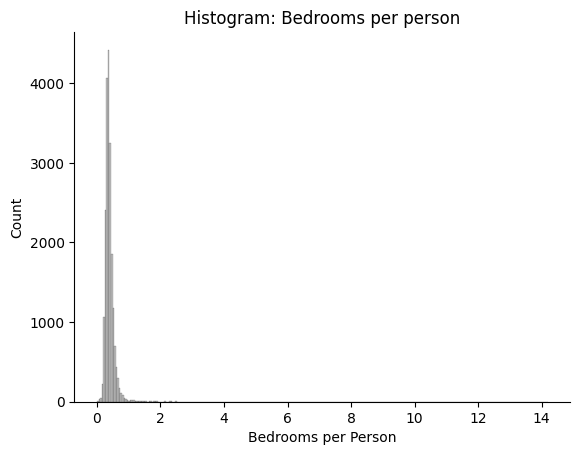

In [28]:
#distribution of bedrooms per person
sns.histplot(data = df, x = 'bedrooms_per_person')
plt.title('Histogram: Bedrooms per person')
plt.xlabel('Bedrooms per Person')
plt.gca().spines[['top', 'right']].set_visible(False)
plt.show()


The visualization shows that most households have low bedrooms per person, with values heavily concentrated near zero. The distribution is right-skewed, with a few rare outliers indicating unusually high space per person.

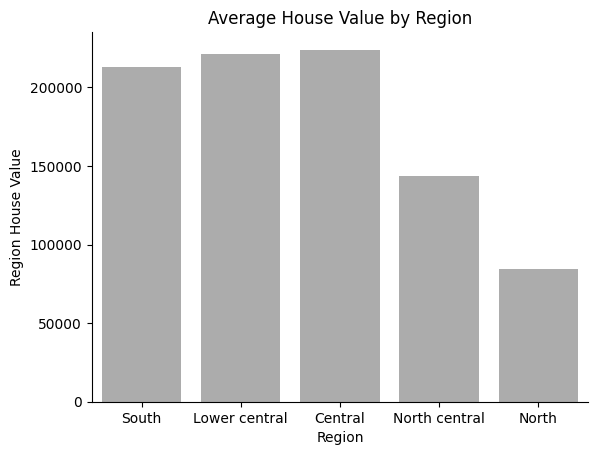

In [29]:
# median house value across different regions
sns.barplot(data = df, x = 'region', y = 'median_house_value', errorbar = ('ci',False))
plt.title('Average House Value by Region')
plt.xlabel('Region')
plt.ylabel('Region House Value')
plt.gca().spines[['top', 'right']].set_visible(False)
plt.show()

The bar chart shows that average house values vary significantly by region. The Central and Lower Central regions have the highest average house values, followed closely by the South, indicating these areas are relatively more expensive. In contrast, the North Central region has moderate prices, while the North region has the lowest average house values, suggesting it is the most affordable. Overall, the visualization highlights clear regional disparities in housing prices, likely influenced by differences in economic conditions, demand, and development levels.